In [39]:
import pandas as pd
import seaborn as sns

In [40]:
df=pd.read_csv("C:/Users/Asus/Downloads/placement_lyst1729240397995.csv")

In [41]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


C:\Users\Asus\AppData\Local\Temp\ipykernel_15232\915735785.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["cgpa"])


<Axes: xlabel='cgpa', ylabel='Density'>

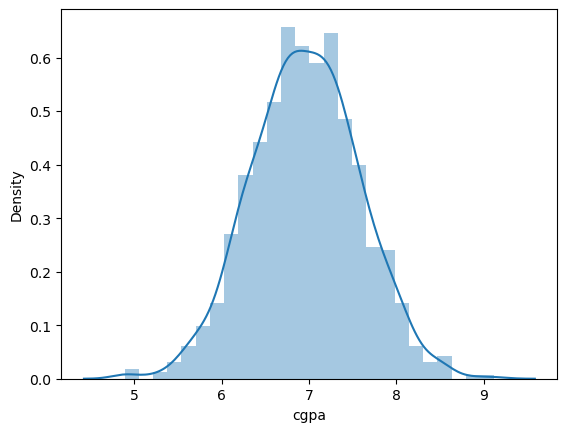

In [42]:
# 1ST - CHECKING IF THE DATA IS NORMALLY DISTRIBUTED OR SKEWED.

sns.distplot(df["cgpa"])

# distplot will give the distribution or kde of the data for judgement.
# it is a perfectly standard normally distributed graph but it has a tale so we will go with z score or emperical rule.

In [43]:
# DETECTING THE OUTLIER WITH 3 STANDARD DEVIATION METHOD OR THE EMPERICAL RULE.
# FINDING THE BOUNDARY

lower_fence=df["cgpa"].mean()-3*(df["cgpa"].std())
upper_fence=df["cgpa"].mean()+3*(df["cgpa"].std())

In [44]:
print(lower_fence)
# any value lower then 5.113546374602832 will be treated.

5.113546374602832


In [45]:
print(upper_fence)
# any value above then 8.808933625397168 will be treated.

8.808933625397168


In [46]:
df[df["cgpa"]<lower_fence]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [47]:
df[upper_fence<df["cgpa"]]

,cgpa,placement_exam_marks,placed
995,8.87,44.0,1
996,9.12,65.0,1


In [61]:
# TREATMENT OF OUTLIERS BY DELETING IT.

clear_data=df[(df["cgpa"]>lower_fence)&(df["cgpa"]<upper_fence)]

In [62]:
print(clear_data)

     cgpa  placement_exam_marks  placed
0    7.19                  26.0       1
1    7.46                  38.0       1
2    7.54                  40.0       1
3    6.42                   8.0       1
4    7.23                  17.0       0
..    ...                   ...     ...
991  7.04                  57.0       0
992  6.26                  12.0       0
993  6.73                  21.0       1
994  6.48                  63.0       0
998  8.62                  46.0       1

[995 rows x 3 columns]


C:\Users\Asus\AppData\Local\Temp\ipykernel_15232\2922321379.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["placement_exam_marks"])


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

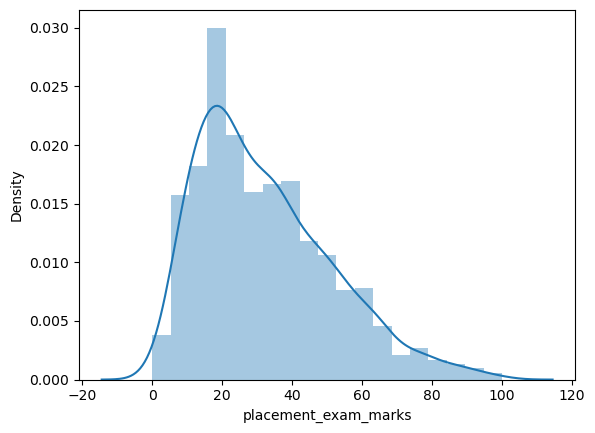

In [48]:
#  NOW FINDING OUTLIERS FOR placement_exam_marks.

sns.distplot(df["placement_exam_marks"])

# this one is positively skewed so we will go with the IQR method to detect outliers.

<Axes: ylabel='placement_exam_marks'>

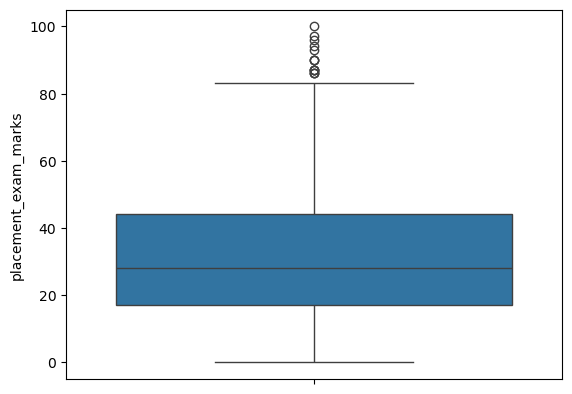

In [49]:
# DETECTION OF OUTLIERS FOR placement_exam_marks USING IQR.

sns.boxplot(y="placement_exam_marks",data=df)

In [50]:
# quartile method is used to find the values of q1 and q3.

q1=df["placement_exam_marks"].quantile(0.25)
q3=df["placement_exam_marks"].quantile(0.75)

In [51]:
print(q1)

17.0


In [52]:
print(q3)

44.0


In [53]:
IQR=q3-q1

In [54]:
# in this formula 1.5 is just the need of the formula.

upper=q3+1.5*(IQR)
lower=q1-1.5*(IQR)

In [55]:
print(upper)

84.5


In [56]:
print(lower)

-23.5


In [57]:
df[upper<df["placement_exam_marks"]]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [63]:
df[lower>df["placement_exam_marks"]]

,cgpa,placement_exam_marks,placed


In [64]:
# CAPING:
import numpy as np

In [68]:
cap=df.copy()

In [71]:
cap["placement_exam_marks"]=np.where(cap["placement_exam_marks"]>upper,upper,
                                     np.where(cap["placement_exam_marks"]<lower,lower,
                                              cap["placement_exam_marks"]))

In [72]:
cap[upper<cap["placement_exam_marks"]]

,cgpa,placement_exam_marks,placed


In [73]:
cap

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1
